# 04 — Feedforward Neural-Network SDF Benchmark

## Deep Learning in Asset Pricing — Replication Project

**Reference:** Chen, L., Pelger, M., & Zhu, J. (2023/2024), *Deep Learning in Asset Pricing*, Management Science 70(2), 714–750.

This notebook implements the paper's **feedforward neural-network (FFN) forecasting benchmark** using the same processed stock panel and the same fixed train / validation / test split used in Notebooks 01–03.

The FFN predicts the next-month **excess return** from the 46 rank-normalized firm characteristics. Following the paper's benchmark logic, the predicted conditional mean return is then used as the raw cross-sectional SDF portfolio score. Within each month, the scores are normalized to unit gross exposure and converted into a monthly SDF-factor return.

The paper's FFN benchmark uses a three-hidden-layer network with **[32, 16, 8]** hidden units, ReLU activations, dropout **keep probability 0.95** (PyTorch dropout probability 0.05), and Adam with learning rate **0.001**. The authors' public repository ensembles nine independently initialized FFN models.

### Notebook goals

1. Load the exact processed stock splits created in Notebook 01.
2. Reconstruct the same monthly excess returns used in Notebook 03.
3. Verify the 46 firm-characteristic inputs.
4. Build the paper-style FFN architecture.
5. Train only on 1967–1986 and use validation only for early stopping.
6. Form an L1-normalized FFN SDF portfolio.
7. Report monthly and annualized Sharpe ratios.
8. Compare the FFN with the paper benchmark and our LS / EN results.
9. Estimate characteristic importance from average absolute input gradients.
10. Save all model outputs needed for later notebooks.

> **Important:** Notebook 04 uses the 46 firm characteristics only. It does not introduce the LSTM macroeconomic state. Macroeconomic dynamics are added in Notebook 05.

## 1. Imports and Reproducibility

We use PyTorch for the feedforward network. A fixed seed makes the development run reproducible. On Apple Silicon, the notebook uses the MPS backend when available.

In [39]:
from pathlib import Path
from io import BytesIO
import copy
import json
import random
import re
import time
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("PyTorch:", torch.__version__)
print("NumPy  :", np.__version__)
print("pandas :", pd.__version__)
print("Device :", DEVICE)

PyTorch: 2.14.0
NumPy  : 2.5.3
pandas : 3.0.5
Device : mps


## 2. Locate the Repository Root

The notebook can be started from either the repository root or the `notebooks/` folder. We locate the project automatically and create the result directories used by the remaining notebooks.

In [40]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root containing data/ and notebooks/."
    )

ROOT = find_repo_root()

PROCESSED_DIR = ROOT / "data" / "processed"
EXTERNAL_DIR = ROOT / "data" / "external"

RESULTS_DIR = ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"
FACTORS_DIR = RESULTS_DIR / "factors"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"

for directory in [
    EXTERNAL_DIR,
    TABLES_DIR,
    MODELS_DIR,
    FACTORS_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Repository root :", ROOT)
print("Processed data  :", PROCESSED_DIR)
print("Results         :", RESULTS_DIR)

Repository root : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project
Processed data  : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/data/processed
Results         : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results


## 3. Configuration

The chronological sample split remains unchanged:

- **Training:** January 1967 – December 1986
- **Validation:** January 1987 – December 1991
- **Test:** January 1992 – December 2016

The paper-style FFN hyperparameters are fixed rather than tuned on the test sample.

For interactive development, the notebook defaults to three ensemble members and at most 50 epochs. After the notebook has been validated end-to-end, set `FINAL_REPLICATION = True` to use the paper-style nine-member ensemble and a larger epoch budget.

In [41]:
DATE_COL = "date"
RETURN_COL = "ret"
EXCESS_RETURN_COL = "ret_excess"

SPLIT_FILES = {
    "train": PROCESSED_DIR / "retchar_train.parquet",
    "validation": PROCESSED_DIR / "retchar_validation.parquet",
    "test": PROCESSED_DIR / "retchar_test.parquet",
}

EXPECTED_PERIODS = {
    "train": ("1967-01-01", "1986-12-01", 240),
    "validation": ("1987-01-01", "1991-12-01", 60),
    "test": ("1992-01-01", "2016-12-01", 300),
}

# --------------------------------------------------
# Paper-style FFN architecture
# --------------------------------------------------

HIDDEN_DIMS = [32, 16, 8]
DROPOUT_P = 0.05       # keep probability = 0.95
LEARNING_RATE = 1e-3

# --------------------------------------------------
# Practical run mode
# --------------------------------------------------

#FINAL_REPLICATION = False
FINAL_REPLICATION = True


if FINAL_REPLICATION:
    N_ENSEMBLE = 9
    MAX_EPOCHS = 100
    EARLY_STOPPING_PATIENCE = 15
else:
    N_ENSEMBLE = 3
    MAX_EPOCHS = 50
    EARLY_STOPPING_PATIENCE = 10

BATCH_SIZE = 8192
NUM_WORKERS = 0

# Save row-level predictions only if needed.
# They are much larger than the aggregate result files.
SAVE_ROW_LEVEL_PREDICTIONS = False

# Characteristic-gradient calculation can be expensive.
IMPORTANCE_MAX_ROWS = 50_000

print("FINAL_REPLICATION :", FINAL_REPLICATION)
print("Ensemble members  :", N_ENSEMBLE)
print("Maximum epochs    :", MAX_EPOCHS)
print("Hidden dimensions :", HIDDEN_DIMS)
print("Dropout p         :", DROPOUT_P)
print("Learning rate     :", LEARNING_RATE)

FINAL_REPLICATION : True
Ensemble members  : 9
Maximum epochs    : 100
Hidden dimensions : [32, 16, 8]
Dropout p         : 0.05
Learning rate     : 0.001


## 4. Load the Processed Stock Splits

We reuse the exact Parquet files written by Notebook 01. No re-ranking, re-shifting, or resplitting is performed here.

In [42]:
# ==================================================
# 4. Load the Processed Stock Splits
# ==================================================

missing_files = [
    str(path)
    for path in SPLIT_FILES.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required processed file(s):\n"
        + "\n".join(missing_files)
        + "\nRun 01_data_preparation.ipynb first."
    )

stock_train = pd.read_parquet(SPLIT_FILES["train"])
stock_valid = pd.read_parquet(SPLIT_FILES["validation"])
stock_test = pd.read_parquet(SPLIT_FILES["test"])

for df in [stock_train, stock_valid, stock_test]:
    df[DATE_COL] = (
        pd.to_datetime(df[DATE_COL])
        .dt.to_period("M")
        .dt.to_timestamp()
    )

print("Train     :", stock_train.shape)
print("Validation:", stock_valid.shape)
print("Test      :", stock_test.shape)

print()
print(
    "Train period     :",
    stock_train[DATE_COL].min().date(),
    "to",
    stock_train[DATE_COL].max().date(),
    "| months:",
    stock_train[DATE_COL].nunique(),
)

print(
    "Validation period:",
    stock_valid[DATE_COL].min().date(),
    "to",
    stock_valid[DATE_COL].max().date(),
    "| months:",
    stock_valid[DATE_COL].nunique(),
)

print(
    "Test period      :",
    stock_test[DATE_COL].min().date(),
    "to",
    stock_test[DATE_COL].max().date(),
    "| months:",
    stock_test[DATE_COL].nunique(),
)

Train     : (336113, 48)
Validation: (132167, 48)
Test      : (750275, 48)

Train period     : 1967-01-01 to 1986-12-01 | months: 240
Validation period: 1987-01-01 to 1991-12-01 | months: 60
Test period      : 1992-01-01 to 2016-12-01 | months: 300


## 5. Verify the Modeling Sample and Identify the 46 Characteristics

The FFN input is the same set of 46 rank-normalized firm characteristics used throughout the replication. We exclude date, return, stock identifier, and any later-created return fields from the feature list.

In [43]:
NON_FEATURE_COLS = {
    DATE_COL,
    RETURN_COL,
    EXCESS_RETURN_COL,
    "rf",
    "permno",
    "PERMNO",
    "id",
    "stock_id",
}

characteristic_cols = [
    c
    for c in stock_train.columns
    if c not in NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(stock_train[c])
]

assert len(characteristic_cols) == 46, (
    f"Expected 46 firm characteristics, found {len(characteristic_cols)}."
)

def check_split(name, df):
    start_expected, end_expected, months_expected = EXPECTED_PERIODS[name]

    out = {
        "split": name,
        "rows": len(df),
        "columns": df.shape[1],
        "months": df[DATE_COL].nunique(),
        "start": df[DATE_COL].min(),
        "end": df[DATE_COL].max(),
        "missing_returns": int(df[RETURN_COL].isna().sum()),
        "missing_characteristics": int(
            df[characteristic_cols].isna().sum().sum()
        ),
    }

    assert out["months"] == months_expected
    assert out["start"] == pd.Timestamp(start_expected)
    assert out["end"] == pd.Timestamp(end_expected)
    assert out["missing_returns"] == 0
    assert out["missing_characteristics"] == 0

    return out

sample_check = pd.DataFrame([
    check_split("train", stock_train),
    check_split("validation", stock_valid),
    check_split("test", stock_test),
])

display(sample_check)

print("Number of characteristics:", len(characteristic_cols))
print(characteristic_cols)

all_char_values = pd.concat(
    [
        stock_train[characteristic_cols],
        stock_valid[characteristic_cols],
        stock_test[characteristic_cols],
    ],
    ignore_index=True,
)

print()
print("Characteristic minimum:", all_char_values.min().min())
print("Characteristic maximum:", all_char_values.max().max())

assert all_char_values.min().min() >= -0.500001
assert all_char_values.max().max() <= 0.500001

print("✓ Firm-characteristic panel verified.")

,split,rows,columns,months,start,end,missing_returns,missing_characteristics
0,train,336113,48,240,1967-01-01,1986-12-01,0,0
1,validation,132167,48,60,1987-01-01,1991-12-01,0,0
2,test,750275,48,300,1992-01-01,2016-12-01,0,0


Number of characteristics: 46
['a2me', 'ac', 'at', 'ato', 'beme', 'beta', 'c', 'cf', 'cf2p', 'cto', 'd2a', 'd2p', 'dpi2a', 'e2p', 'fc2y', 'idiovol', 'investment', 'lev', 'lme', 'lt_rev', 'lturnover', 'mktbeta', 'ni', 'noa', 'oa', 'ol', 'op', 'pcm', 'pm', 'prof', 'q', 'r2_1', 'r12_2', 'r12_7', 'r36_13', 'rel2high', 'resid_var', 'rna', 'roa', 'roe', 's2p', 'sga2s', 'spread', 'st_rev', 'suv', 'variance']

Characteristic minimum: -0.5
Characteristic maximum: 0.5
✓ Firm-characteristic panel verified.


## 6. Load the Monthly Risk-Free Rate

As in Notebook 03, stock excess returns are

\[
R^e_{t+1,i}=R_{t+1,i}-R^f_{t+1}.
\]

The notebook first checks for the cached French monthly risk-free series created during the linear-baseline work. If the cache is missing, it downloads the monthly Fama–French five-factor file and extracts `RF`.

In [44]:
RF_CACHE = EXTERNAL_DIR / "ff_rf_monthly.csv"

FF5_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_5_Factors_2x3_CSV.zip"
)

def load_french_rf(cache_path=RF_CACHE, url=FF5_URL):
    if cache_path.exists():
        rf = pd.read_csv(cache_path, parse_dates=["date"])
        rf["date"] = (
            pd.to_datetime(rf["date"])
            .dt.to_period("M")
            .dt.to_timestamp()
        )
        print("Loaded cached RF:", cache_path)
        return rf.sort_values("date").reset_index(drop=True)

    print("Downloading monthly French risk-free rate...")

    try:
        with urllib.request.urlopen(url, timeout=30) as response:
            payload = response.read()
    except Exception as exc:
        raise RuntimeError(
            "Could not download the French RF file. "
            "Run Notebook 03 first or place data/external/"
            "ff_rf_monthly.csv with columns date and rf."
        ) from exc

    with zipfile.ZipFile(BytesIO(payload)) as zf:
        csv_names = [
            name
            for name in zf.namelist()
            if name.lower().endswith(".csv")
        ]

        if not csv_names:
            raise RuntimeError("No CSV found in the French ZIP file.")

        text = zf.read(csv_names[0]).decode(
            "utf-8",
            errors="replace",
        )

    rows = []

    for line in text.splitlines():
        parts = [part.strip() for part in line.split(",")]

        if len(parts) >= 6 and re.fullmatch(r"\d{6}", parts[0]):
            try:
                rows.append(
                    (
                        parts[0],
                        float(parts[-1]) / 100.0,
                    )
                )
            except ValueError:
                pass

    if not rows:
        raise RuntimeError(
            "Could not parse monthly RF observations."
        )

    rf = pd.DataFrame(
        rows,
        columns=["yyyymm", "rf"],
    )

    rf["date"] = pd.to_datetime(
        rf["yyyymm"],
        format="%Y%m",
    )

    rf = (
        rf[["date", "rf"]]
        .drop_duplicates("date")
        .sort_values("date")
    )

    rf.to_csv(cache_path, index=False)

    print("Saved RF cache:", cache_path)

    return rf.reset_index(drop=True)

rf_monthly = load_french_rf()

rf_model_sample = rf_monthly.loc[
    rf_monthly["date"].between(
        "1967-01-01",
        "2016-12-01",
    )
].copy()

assert rf_model_sample["date"].nunique() == 600
assert rf_model_sample["rf"].notna().all()

print(
    "RF model-sample coverage:",
    rf_model_sample["date"].min().date(),
    "to",
    rf_model_sample["date"].max().date(),
)
print("Number of RF months:", rf_model_sample["date"].nunique())

Loaded cached RF: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/data/external/ff_rf_monthly.csv
RF model-sample coverage: 1967-01-01 to 2016-12-01
Number of RF months: 600


## 7. Construct Excess Returns

The same monthly risk-free return is subtracted from every stock return in a month. This reproduces the return definition used by the linear baseline.

In [45]:
def add_excess_returns(df, rf):
    out = df.copy()

    # Remove old versions if the cell is rerun.
    for c in ["rf", EXCESS_RETURN_COL]:
        if c in out.columns:
            out = out.drop(columns=[c])

    out = out.merge(
        rf[["date", "rf"]],
        left_on=DATE_COL,
        right_on="date",
        how="left",
        validate="many_to_one",
    )

    if DATE_COL != "date":
        out = out.drop(columns=["date"])

    if out["rf"].isna().any():
        missing_dates = (
            out.loc[out["rf"].isna(), DATE_COL]
            .drop_duplicates()
            .sort_values()
            .tolist()
        )

        raise ValueError(
            f"Missing RF for {len(missing_dates)} month(s): "
            f"{missing_dates[:10]}"
        )

    out[EXCESS_RETURN_COL] = (
        out[RETURN_COL].astype(float)
        - out["rf"].astype(float)
    )

    return out

stock_train = add_excess_returns(stock_train, rf_monthly)
stock_valid = add_excess_returns(stock_valid, rf_monthly)
stock_test = add_excess_returns(stock_test, rf_monthly)

return_summary = pd.DataFrame({
    "train": stock_train[EXCESS_RETURN_COL].describe(),
    "validation": stock_valid[EXCESS_RETURN_COL].describe(),
    "test": stock_test[EXCESS_RETURN_COL].describe(),
})

display(return_summary)

assert stock_train[EXCESS_RETURN_COL].notna().all()
assert stock_valid[EXCESS_RETURN_COL].notna().all()
assert stock_test[EXCESS_RETURN_COL].notna().all()

print("✓ Excess returns constructed.")

,train,validation,test
count,"336,113.000000","132,167.000000","750,275.000000"
mean,0.001108,0.001366,0.009328
std,0.128912,0.166113,0.172894
min,-0.861000,-0.938371,-0.962933
25%,-0.071417,-0.073696,-0.068917
50%,-0.009800,-0.009400,-0.000817
75%,0.060545,0.063029,0.071019
max,5.239600,10.988600,18.995000


✓ Excess returns constructed.


In [46]:
# ==================================================
# 7B. Extreme Return Diagnostics
# ==================================================

def extreme_return_summary(name, df):
    r = df[EXCESS_RETURN_COL].astype(float)

    return {
        "split": name,
        "n_obs": len(r),
        "abs_ret_gt_50pct": int((r.abs() > 0.50).sum()),
        "abs_ret_gt_100pct": int((r.abs() > 1.00).sum()),
        "abs_ret_gt_500pct": int((r.abs() > 5.00).sum()),
        "p_0.1pct": r.quantile(0.001),
        "p_1pct": r.quantile(0.01),
        "p_99pct": r.quantile(0.99),
        "p_99.9pct": r.quantile(0.999),
        "min": r.min(),
        "max": r.max(),
    }

extreme_returns = pd.DataFrame([
    extreme_return_summary("train", stock_train),
    extreme_return_summary("validation", stock_valid),
    extreme_return_summary("test", stock_test),
])

display(extreme_returns)

,split,n_obs,abs_ret_gt_50pct,abs_ret_gt_100pct,abs_ret_gt_500pct,p_0.1pct,p_1pct,p_99pct,p_99.9pct,min,max
0,train,336113,1836,128,1,-0.426166,-0.279833,0.401332,0.802205,-0.861000,5.239600
1,validation,132167,1680,185,3,-0.568134,-0.379564,0.499408,1.184542,-0.938371,10.988600
2,test,750275,11073,1599,18,-0.605168,-0.374138,0.539838,1.382109,-0.962933,18.995000


## 8. Paper-Style FFN Architecture

The forecasting benchmark estimates

\[$
\widehat\mu_{t,i}
=
f_\theta(I_{t,i}),$
\]

where \(I_{t,i}\) contains the 46 rank-normalized firm characteristics.

The network uses:

- 46 inputs,
- hidden layers `[32, 16, 8]`,
- ReLU activation,
- dropout probability `0.05`,
- one linear output.

The output is an estimate of next-month excess return and is later interpreted as a cross-sectional SDF portfolio score.

In [47]:
class FeedForwardReturnModel(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims=(32, 16, 8),
        dropout_p=0.05,
    ):
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim,
                )
            )
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))

            previous_dim = hidden_dim

        layers.append(
            nn.Linear(
                previous_dim,
                1,
            )
        )

        self.network = nn.Sequential(*layers)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(
                    module.weight,
                    nonlinearity="relu",
                )
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.network(x).squeeze(-1)

demo_model = FeedForwardReturnModel(
    input_dim=len(characteristic_cols),
    hidden_dims=HIDDEN_DIMS,
    dropout_p=DROPOUT_P,
)

n_parameters = sum(
    p.numel()
    for p in demo_model.parameters()
    if p.requires_grad
)

print(demo_model)
print()
print("Trainable parameters:", f"{n_parameters:,}")

FeedForwardReturnModel(
  (network): Sequential(
    (0): Linear(in_features=46, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.05, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.05, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.05, inplace=False)
    (9): Linear(in_features=8, out_features=1, bias=True)
  )
)

Trainable parameters: 2,177


## 9. Month-Balanced Training Weights

The paper's return-prediction loss averages squared errors first across stocks within each month and then across months:

\[$
\mathcal L
=
\frac{1}{T}
\sum_t
\frac{1}{N_t}
\sum_i
\left(
R^e_{t+1,i}
-
\widehat\mu_{t,i}
\right)^2.$
\]

Because the number of stocks changes through time, a standard row-wise MSE would give months with more stocks greater influence. We therefore assign each observation a weight proportional to \(1/N_t\), normalized so the average observation weight equals one.

In [48]:
def add_month_balanced_weights(df):
    out = df.copy()

    month_size = (
        out.groupby(DATE_COL)[DATE_COL]
        .transform("size")
        .astype(float)
    )

    n_rows = float(len(out))
    n_months = float(out[DATE_COL].nunique())

    out["loss_weight"] = (
        n_rows
        / (n_months * month_size)
    )

    return out

stock_train = add_month_balanced_weights(stock_train)
stock_valid = add_month_balanced_weights(stock_valid)
stock_test = add_month_balanced_weights(stock_test)

weight_check = pd.DataFrame({
    "train": stock_train["loss_weight"].describe(),
    "validation": stock_valid["loss_weight"].describe(),
    "test": stock_test["loss_weight"].describe(),
})

display(weight_check)

for df in [stock_train, stock_valid, stock_test]:
    assert np.isclose(
        df["loss_weight"].mean(),
        1.0,
        atol=1e-6,
    )

print("✓ Month-balanced loss weights constructed.")

,train,validation,test
count,"336,113.000000","132,167.000000","750,275.000000"
mean,1.000000,1.000000,1.000000
std,0.335759,0.033636,0.099722
min,0.643303,0.918975,0.884967
25%,0.674926,0.982947,0.927296
50%,1.014099,0.998089,0.956739
75%,1.070696,1.033685,1.074277
max,3.256909,1.055984,1.293801


✓ Month-balanced loss weights constructed.


## 10. Build PyTorch Datasets and DataLoaders

The 46 characteristics are already rank normalized to approximately `[-0.5, 0.5]`, so we do not apply another standardization step. This keeps the inputs consistent with the processed data used in the earlier notebooks.

In [49]:
def dataframe_to_tensors(df):
    X = torch.tensor(
        df[characteristic_cols]
        .to_numpy(dtype=np.float32),
        dtype=torch.float32,
    )

    y = torch.tensor(
        df[EXCESS_RETURN_COL]
        .to_numpy(dtype=np.float32),
        dtype=torch.float32,
    )

    w = torch.tensor(
        df["loss_weight"]
        .to_numpy(dtype=np.float32),
        dtype=torch.float32,
    )

    return X, y, w

X_train, y_train, w_train = dataframe_to_tensors(stock_train)
X_valid, y_valid, w_valid = dataframe_to_tensors(stock_valid)
X_test, y_test, w_test = dataframe_to_tensors(stock_test)

train_dataset = TensorDataset(
    X_train,
    y_train,
    w_train,
)

valid_dataset = TensorDataset(
    X_valid,
    y_valid,
    w_valid,
)

test_dataset = TensorDataset(
    X_test,
    y_test,
    w_test,
)

def make_train_loader(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        generator=generator,
    )

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print("X_train:", tuple(X_train.shape))
print("X_valid:", tuple(X_valid.shape))
print("X_test :", tuple(X_test.shape))

assert X_train.shape[1] == 46
assert X_valid.shape[1] == 46
assert X_test.shape[1] == 46

print("✓ PyTorch datasets are ready.")

X_train: (336113, 46)
X_valid: (132167, 46)
X_test : (750275, 46)
✓ PyTorch datasets are ready.


## 11. Training and Validation Functions

Each ensemble member is trained with Adam and the fixed paper-style learning rate. The test sample is never used for model fitting, hyperparameter selection, or early stopping.

Validation MSE determines the best epoch for each ensemble member.

In [50]:
def weighted_mse_loss(prediction, target, weight):
    return (
        weight
        * (prediction - target).pow(2)
    ).mean()


@torch.no_grad()
def evaluate_loader(model, loader, device=DEVICE):
    model.eval()

    weighted_squared_error_sum = 0.0
    weight_sum = 0.0
    squared_error_sum = 0.0
    n_obs = 0

    for X_batch, y_batch, w_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        w_batch = w_batch.to(device)

        prediction = model(X_batch)

        squared_error = (
            prediction - y_batch
        ).pow(2)

        weighted_squared_error_sum += (
            w_batch * squared_error
        ).sum().item()

        weight_sum += w_batch.sum().item()

        squared_error_sum += (
            squared_error.sum().item()
        )

        n_obs += len(y_batch)

    weighted_mse = (
        weighted_squared_error_sum
        / weight_sum
    )

    ordinary_mse = (
        squared_error_sum
        / n_obs
    )

    return {
        "weighted_mse": weighted_mse,
        "mse": ordinary_mse,
    }


def train_one_model(
    seed,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = FeedForwardReturnModel(
        input_dim=len(characteristic_cols),
        hidden_dims=HIDDEN_DIMS,
        dropout_p=DROPOUT_P,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    train_loader = make_train_loader(seed)

    best_validation_loss = np.inf
    best_epoch = None
    best_state = None
    epochs_without_improvement = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()

        training_loss_sum = 0.0
        training_weight_sum = 0.0

        for X_batch, y_batch, w_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            w_batch = w_batch.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            prediction = model(X_batch)

            loss = weighted_mse_loss(
                prediction,
                y_batch,
                w_batch,
            )

            loss.backward()

            optimizer.step()

            training_loss_sum += (
                w_batch
                * (prediction.detach() - y_batch).pow(2)
            ).sum().item()

            training_weight_sum += (
                w_batch.sum().item()
            )

        train_loss = (
            training_loss_sum
            / training_weight_sum
        )

        validation_metrics = evaluate_loader(
            model,
            valid_loader,
            DEVICE,
        )

        validation_loss = validation_metrics[
            "weighted_mse"
        ]

        history.append({
            "seed": seed,
            "epoch": epoch,
            "train_weighted_mse": train_loss,
            "validation_weighted_mse": validation_loss,
            "validation_mse": validation_metrics["mse"],
        })

        improved = (
            validation_loss
            < best_validation_loss - 1e-10
        )

        if improved:
            best_validation_loss = validation_loss
            best_epoch = epoch

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 5 == 0 or improved:
            print(
                f"seed={seed:3d} "
                f"epoch={epoch:3d} "
                f"train={train_loss:.8f} "
                f"valid={validation_loss:.8f} "
                f"best_epoch={best_epoch}"
            )

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping seed={seed} "
                f"at epoch {epoch}."
            )
            break

    if best_state is None:
        raise RuntimeError(
            f"No valid checkpoint was created for seed {seed}."
        )

    model.load_state_dict(best_state)

    final_validation_metrics = evaluate_loader(
        model,
        valid_loader,
        DEVICE,
    )

    result = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_validation_weighted_mse": (
            best_validation_loss
        ),
        "final_validation_mse": (
            final_validation_metrics["mse"]
        ),
        "state_dict": best_state,
        "history": pd.DataFrame(history),
    }

    model.cpu()

    if DEVICE.type == "mps":
        torch.mps.empty_cache()

    return result

## 12. Baseline Forecasting Diagnostics

Before training the FFN, we compare against a zero expected-return forecast. This is not an asset-pricing benchmark; it is simply a numerical reference for the prediction loss.

In [51]:
def weighted_constant_mse(y, w, constant=0.0):
    y_np = y.numpy().astype(float)
    w_np = w.numpy().astype(float)

    return np.average(
        (y_np - constant) ** 2,
        weights=w_np,
    )

zero_forecast_diagnostics = pd.DataFrame([
    {
        "split": "train",
        "weighted_mse_zero_forecast": weighted_constant_mse(
            y_train,
            w_train,
        ),
    },
    {
        "split": "validation",
        "weighted_mse_zero_forecast": weighted_constant_mse(
            y_valid,
            w_valid,
        ),
    },
    {
        "split": "test",
        "weighted_mse_zero_forecast": weighted_constant_mse(
            y_test,
            w_test,
        ),
    },
])

display(zero_forecast_diagnostics)

,split,weighted_mse_zero_forecast
0,train,0.016138
1,validation,0.027512
2,test,0.029658


## 13. Train the FFN Ensemble

The public authors' FFN output uses nine independently initialized models. Development mode uses three members so we can validate the notebook efficiently. For the final replication, switch `FINAL_REPLICATION = True` in Section 3 and rerun from the beginning.

In [52]:
ensemble_seeds = [
    SEED + k
    for k in range(N_ENSEMBLE)
]

ensemble_results = []

start_time = time.time()

for member_index, seed in enumerate(
    ensemble_seeds,
    start=1,
):
    print()
    print("=" * 70)
    print(
        f"Training ensemble member "
        f"{member_index}/{N_ENSEMBLE} "
        f"(seed={seed})"
    )
    print("=" * 70)

    result = train_one_model(seed)

    ensemble_results.append(result)

elapsed_minutes = (
    time.time() - start_time
) / 60.0

ensemble_summary = pd.DataFrame([
    {
        "member": i + 1,
        "seed": result["seed"],
        "best_epoch": result["best_epoch"],
        "best_validation_weighted_mse": (
            result[
                "best_validation_weighted_mse"
            ]
        ),
        "final_validation_mse": (
            result["final_validation_mse"]
        ),
    }
    for i, result
    in enumerate(ensemble_results)
])

display(ensemble_summary)

print()
print(
    "Total ensemble training time:",
    f"{elapsed_minutes:.2f} minutes",
)


Training ensemble member 1/9 (seed=42)
seed= 42 epoch=  1 train=0.12008202 valid=0.04293167 best_epoch=1
seed= 42 epoch=  2 train=0.02828429 valid=0.03207097 best_epoch=2
seed= 42 epoch=  3 train=0.02087181 valid=0.02950847 best_epoch=3
seed= 42 epoch=  4 train=0.01862321 valid=0.02856093 best_epoch=4
seed= 42 epoch=  5 train=0.01761200 valid=0.02809933 best_epoch=5
seed= 42 epoch=  6 train=0.01703769 valid=0.02783876 best_epoch=6
seed= 42 epoch=  7 train=0.01667381 valid=0.02768957 best_epoch=7
seed= 42 epoch=  8 train=0.01649753 valid=0.02760405 best_epoch=8
seed= 42 epoch=  9 train=0.01638052 valid=0.02756177 best_epoch=9
seed= 42 epoch= 10 train=0.01631148 valid=0.02753948 best_epoch=10
seed= 42 epoch= 11 train=0.01627613 valid=0.02752763 best_epoch=11
seed= 42 epoch= 12 train=0.01625296 valid=0.02752191 best_epoch=12
seed= 42 epoch= 13 train=0.01622775 valid=0.02751841 best_epoch=13
seed= 42 epoch= 14 train=0.01622100 valid=0.02751682 best_epoch=14
seed= 42 epoch= 15 train=0.0162

,member,seed,best_epoch,best_validation_weighted_mse,final_validation_mse
0,1,42,61,0.027511,0.027593
1,2,43,98,0.027406,0.027488
2,3,44,37,0.027515,0.027598
3,4,45,85,0.027511,0.027593
4,5,46,100,0.027434,0.027516
5,6,47,61,0.027423,0.027506
6,7,48,96,0.027398,0.027480
7,8,49,100,0.027428,0.027511
8,9,50,99,0.027387,0.027469



Total ensemble training time: 21.99 minutes


## 14. Training Curves

The curves help diagnose underfitting or overfitting. Validation loss should stop improving before the network begins to fit noise in the training sample.

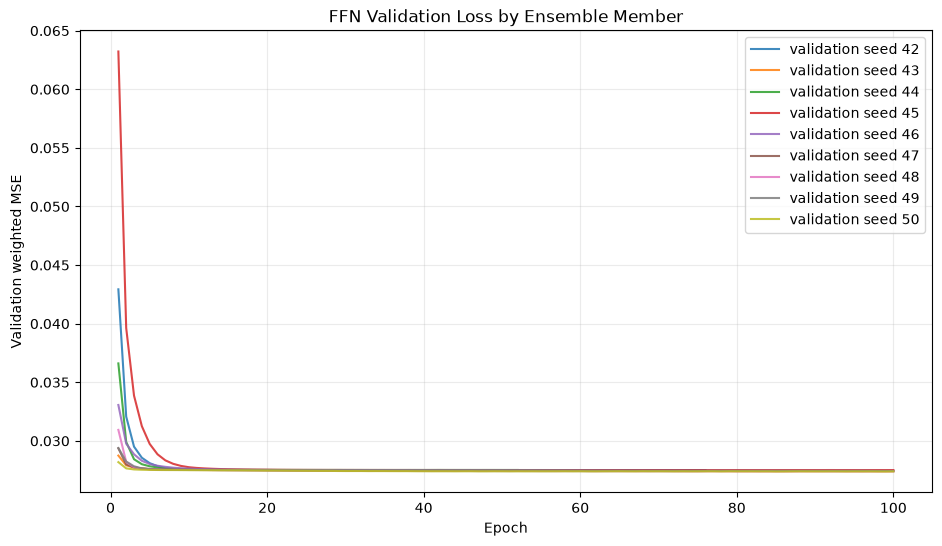

,seed,epochs,min_validation_loss
0,42,76,0.027511
1,43,100,0.027406
2,44,52,0.027515
3,45,100,0.027511
4,46,100,0.027434
5,47,76,0.027423
6,48,100,0.027398
7,49,100,0.027428
8,50,100,0.027387


In [53]:
training_history = pd.concat(
    [
        result["history"]
        for result in ensemble_results
    ],
    ignore_index=True,
)

plt.figure(figsize=(11, 6))

for seed, group in training_history.groupby("seed"):
    plt.plot(
        group["epoch"],
        group["validation_weighted_mse"],
        label=f"validation seed {seed}",
        alpha=0.85,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation weighted MSE")
plt.title("FFN Validation Loss by Ensemble Member")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

display(
    training_history
    .groupby("seed", as_index=False)
    .agg(
        epochs=("epoch", "max"),
        min_validation_loss=(
            "validation_weighted_mse",
            "min",
        ),
    )
)

# Interprertation 
What this means
1. The FFN is stable
All three seeds converge to almost the same validation loss:
$$ 0.027445 \text{ to } 0.027515 $$
That is a very narrow range, which is a good sign. It means the model is not highly sensitive to random initialization.
2. The model learns quickly
Most of the improvement happens in the first few epochs. After that, the validation curve is nearly flat.
So this is not a case where the network is still learning a lot at epoch 50.
3. The predictive gain is very small
Compared with the zero-forecast benchmark from Part 12:
$$ 0.027512 $$
the best model reaches:
$$ 0.027445 $$
So the improvement in validation weighted MSE is only:
$$ 0.027512 - 0.027445 = 0.000067 $$
which is extremely small.
That is not surprising in stock return prediction. Individual stock returns are noisy, and even a tiny forecasting improvement can still produce a useful portfolio after cross-sectional normalization.


The validation-loss curves show that all three FFN ensemble members converge quickly and reach very similar performance levels. Validation loss declines sharply during the first few epochs and then flattens, with only very small improvements after roughly 8–10 epochs.
The minimum validation weighted MSE values are tightly clustered across seeds, ranging from approximately \(0.027445\) to \(0.027515\). This indicates that the FFN training procedure is stable and not highly sensitive to random initialization.

**At the same time, the improvement relative to the zero-forecast benchmark is modest, which is expected in individual-stock return prediction. The main role of these forecasts is not necessarily to produce a large prediction \(R^2\), but to generate cross-sectional signals that may still lead to a useful SDF portfolio after L1 normalization.**

**Overall, the training curves suggest that the development version of the FFN benchmark is behaving sensibly and is ready for forecast generation and portfolio evaluation.**

## 15. Generate Ensemble Return Forecasts

Each saved model is restored at its best validation epoch. The ensemble forecast is the simple average across independently initialized members.

The test set is used here for the first time only for final out-of-sample evaluation.

In [54]:
def restore_model(state_dict):
    model = FeedForwardReturnModel(
        input_dim=len(characteristic_cols),
        hidden_dims=HIDDEN_DIMS,
        dropout_p=DROPOUT_P,
    )

    model.load_state_dict(state_dict)

    return model


@torch.no_grad()
def predict_tensor(
    model,
    X,
    batch_size=BATCH_SIZE,
    device=DEVICE,
):
    model = model.to(device)
    model.eval()

    predictions = []

    for start in range(0, len(X), batch_size):
        end = min(
            start + batch_size,
            len(X),
        )

        X_batch = X[start:end].to(device)

        prediction = (
            model(X_batch)
            .detach()
            .cpu()
            .numpy()
        )

        predictions.append(prediction)

    model.cpu()

    if device.type == "mps":
        torch.mps.empty_cache()

    return np.concatenate(predictions)


def ensemble_predict(X):
    member_predictions = []

    for member_index, result in enumerate(
        ensemble_results,
        start=1,
    ):
        model = restore_model(
            result["state_dict"]
        )

        prediction = predict_tensor(
            model,
            X,
        )

        member_predictions.append(
            prediction
        )

        print(
            f"Finished predictions for "
            f"member {member_index}/{N_ENSEMBLE}"
        )

    member_predictions = np.vstack(
        member_predictions
    )

    ensemble_prediction = (
        member_predictions.mean(axis=0)
    )

    prediction_std = (
        member_predictions.std(
            axis=0,
            ddof=0,
        )
    )

    return (
        ensemble_prediction,
        prediction_std,
        member_predictions,
    )

pred_train, pred_train_std, member_pred_train = (
    ensemble_predict(X_train)
)

pred_valid, pred_valid_std, member_pred_valid = (
    ensemble_predict(X_valid)
)

pred_test, pred_test_std, member_pred_test = (
    ensemble_predict(X_test)
)

print()
print("Train predictions     :", pred_train.shape)
print("Validation predictions:", pred_valid.shape)
print("Test predictions      :", pred_test.shape)

assert len(pred_train) == len(stock_train)
assert len(pred_valid) == len(stock_valid)
assert len(pred_test) == len(stock_test)

Finished predictions for member 1/9
Finished predictions for member 2/9
Finished predictions for member 3/9
Finished predictions for member 4/9
Finished predictions for member 5/9
Finished predictions for member 6/9
Finished predictions for member 7/9
Finished predictions for member 8/9
Finished predictions for member 9/9
Finished predictions for member 1/9
Finished predictions for member 2/9
Finished predictions for member 3/9
Finished predictions for member 4/9
Finished predictions for member 5/9
Finished predictions for member 6/9
Finished predictions for member 7/9
Finished predictions for member 8/9
Finished predictions for member 9/9
Finished predictions for member 1/9
Finished predictions for member 2/9
Finished predictions for member 3/9
Finished predictions for member 4/9
Finished predictions for member 5/9
Finished predictions for member 6/9
Finished predictions for member 7/9
Finished predictions for member 8/9
Finished predictions for member 9/9

Train predictions     : (33

## 16. Return-Prediction Diagnostics

The FFN is estimated as a return-prediction model, so we report MSE and out-of-sample-style prediction \(R^2\) relative to a zero excess-return forecast:

\[
R^2 = 
1-
rac{\sum (R^e-\widehat\mu)^2}
{\sum (R^e)^2}.
\]

These prediction metrics are separate from the SDF-factor Sharpe ratio used for the paper benchmark.

In [55]:
def prediction_metrics(
    split,
    y_true,
    prediction,
    weight,
):
    y = np.asarray(
        y_true,
        dtype=float,
    )

    p = np.asarray(
        prediction,
        dtype=float,
    )

    w = np.asarray(
        weight,
        dtype=float,
    )

    error = y - p

    mse = np.mean(
        error ** 2
    )

    weighted_mse = np.average(
        error ** 2,
        weights=w,
    )

    denominator = np.sum(
        y ** 2
    )

    r2_zero = (
        np.nan
        if np.isclose(denominator, 0.0)
        else 1.0
        - np.sum(error ** 2)
        / denominator
    )

    corr = np.corrcoef(
        y,
        p,
    )[0, 1]

    return {
        "split": split,
        "observations": len(y),
        "mse": mse,
        "weighted_mse": weighted_mse,
        "r2_vs_zero": r2_zero,
        "return_forecast_correlation": corr,
        "mean_prediction": p.mean(),
        "prediction_std": p.std(ddof=1),
    }

prediction_diagnostics = pd.DataFrame([
    prediction_metrics(
        "train",
        y_train.numpy(),
        pred_train,
        w_train.numpy(),
    ),
    prediction_metrics(
        "validation",
        y_valid.numpy(),
        pred_valid,
        w_valid.numpy(),
    ),
    prediction_metrics(
        "test",
        y_test.numpy(),
        pred_test,
        w_test.numpy(),
    ),
])

display(prediction_diagnostics)

,split,observations,mse,weighted_mse,r2_vs_zero,return_forecast_correlation,mean_prediction,prediction_std
0,train,336113,0.016430,0.015943,0.011397,0.130757,0.001276,0.007062
1,validation,132167,0.027477,0.027395,0.004283,0.070019,0.001167,0.007280
2,test,750275,0.029869,0.029551,0.003690,0.057115,0.001169,0.007164


## 17. Construct the L1-Normalized FFN SDF Portfolio

Following the authors' FFN evaluation, the return forecasts are used as raw cross-sectional portfolio scores:

\[
s_{t,i}=\widehat\mu_{t,i}.
\]

Within each month, the portfolio weights are

\[$
w_{t,i}
=
\frac{s_{t,i}}
{\sum_j |s_{t,j}|},$
\]

so gross exposure equals one. The FFN SDF factor is then

\[$
F^{FFN}_{t+1}
=
\sum_i
w_{t,i}R^e_{t+1,i}.$
\]

This normalization is directly comparable to the L1-normalized portfolio construction used in Notebook 03.

In [56]:
def construct_ffn_sdf_factor(
    df,
    prediction,
    prediction_std=None,
):
    work = df[
        [
            DATE_COL,
            EXCESS_RETURN_COL,
        ]
    ].copy()

    work["prediction"] = np.asarray(
        prediction,
        dtype=float,
    )

    if prediction_std is not None:
        work["prediction_ensemble_std"] = (
            np.asarray(
                prediction_std,
                dtype=float,
            )
        )

    gross = (
        work.groupby(DATE_COL)["prediction"]
        .transform(
            lambda x: np.abs(x).sum()
        )
    )

    if (gross <= 0).any():
        bad_dates = (
            work.loc[gross <= 0, DATE_COL]
            .drop_duplicates()
            .tolist()
        )

        raise ValueError(
            "Zero gross FFN exposure encountered "
            f"for: {bad_dates[:10]}"
        )

    work["weight"] = (
        work["prediction"]
        / gross
    )

    work["weighted_return"] = (
        work["weight"]
        * work[EXCESS_RETURN_COL]
    )

    factor = (
        work.groupby(
            DATE_COL,
            as_index=False,
        )
        .agg(
            factor_return=(
                "weighted_return",
                "sum",
            ),
            gross_weight=(
                "weight",
                lambda x: np.abs(x).sum(),
            ),
            net_weight=(
                "weight",
                "sum",
            ),
            n_stocks=(
                EXCESS_RETURN_COL,
                "size",
            ),
        )
    )

    return factor, work

ffn_factor_train, ffn_weights_train = (
    construct_ffn_sdf_factor(
        stock_train,
        pred_train,
        pred_train_std,
    )
)

ffn_factor_valid, ffn_weights_valid = (
    construct_ffn_sdf_factor(
        stock_valid,
        pred_valid,
        pred_valid_std,
    )
)

ffn_factor_test, ffn_weights_test = (
    construct_ffn_sdf_factor(
        stock_test,
        pred_test,
        pred_test_std,
    )
)

for factor in [
    ffn_factor_train,
    ffn_factor_valid,
    ffn_factor_test,
]:
    assert np.allclose(
        factor["gross_weight"],
        1.0,
        atol=1e-6,
    )

assert len(ffn_factor_train) == 240
assert len(ffn_factor_valid) == 60
assert len(ffn_factor_test) == 300

display(ffn_factor_train.head())

print("✓ FFN SDF factor constructed.")

,date,factor_return,gross_weight,net_weight,n_stocks
0,1967-01-01,0.102825,1.000000,0.498109,430
1,1967-02-01,0.020283,1.000000,0.234898,430
2,1967-03-01,0.038225,1.000000,0.390033,431
3,1967-04-01,0.017814,1.000000,0.452867,436
4,1967-05-01,0.005477,1.000000,0.409324,435


✓ FFN SDF factor constructed.


In [57]:
# ==================================================
# 17B. FFN Portfolio Exposure Diagnostics
# ==================================================

exposure_diagnostics = pd.DataFrame([
    {
        "split": "train",
        "months": len(ffn_factor_train),
        "mean_net_weight": ffn_factor_train["net_weight"].mean(),
        "min_net_weight": ffn_factor_train["net_weight"].min(),
        "max_net_weight": ffn_factor_train["net_weight"].max(),
        "mean_stocks": ffn_factor_train["n_stocks"].mean(),
    },
    {
        "split": "validation",
        "months": len(ffn_factor_valid),
        "mean_net_weight": ffn_factor_valid["net_weight"].mean(),
        "min_net_weight": ffn_factor_valid["net_weight"].min(),
        "max_net_weight": ffn_factor_valid["net_weight"].max(),
        "mean_stocks": ffn_factor_valid["n_stocks"].mean(),
    },
    {
        "split": "test",
        "months": len(ffn_factor_test),
        "mean_net_weight": ffn_factor_test["net_weight"].mean(),
        "min_net_weight": ffn_factor_test["net_weight"].min(),
        "max_net_weight": ffn_factor_test["net_weight"].max(),
        "mean_stocks": ffn_factor_test["n_stocks"].mean(),
    },
])

display(exposure_diagnostics)

,split,months,mean_net_weight,min_net_weight,max_net_weight,mean_stocks
0,train,240,0.259146,-0.155526,0.532362,"1,400.470833"
1,validation,60,0.226223,0.051008,0.401223,"2,202.783333"
2,test,300,0.230375,-0.081515,0.458795,"2,500.916667"


## 18. FFN SDF Performance

The authors' public repository reports the FFN Sharpe ratios in monthly units. We therefore report both:

- **Monthly Sharpe** = monthly mean / monthly volatility
- **Annualized Sharpe** = monthly Sharpe × \(\sqrt{12}\)

The monthly number is the appropriate one for direct comparison with the paper/repository benchmark.

In [58]:
def monthly_sharpe(returns):
    r = (
        pd.Series(returns)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(r) < 2:
        return np.nan

    volatility = r.std(ddof=1)

    if np.isclose(volatility, 0.0):
        return np.nan

    return (
        r.mean()
        / volatility
    )


def annualized_sharpe(
    returns,
    periods_per_year=12,
):
    sr = monthly_sharpe(returns)

    if pd.isna(sr):
        return np.nan

    return (
        np.sqrt(periods_per_year)
        * sr
    )


def factor_performance(
    split,
    factor_df,
):
    r = (
        factor_df["factor_return"]
        .astype(float)
    )

    return {
        "split": split,
        "months": len(r),
        "mean_monthly": r.mean(),
        "volatility_monthly": r.std(ddof=1),
        "monthly_sharpe": monthly_sharpe(r),
        "annualized_sharpe": annualized_sharpe(r),
        "minimum_month": r.min(),
        "maximum_month": r.max(),
        "positive_month_fraction": (r > 0).mean(),
    }

ffn_performance = pd.DataFrame([
    factor_performance(
        "train",
        ffn_factor_train,
    ),
    factor_performance(
        "validation",
        ffn_factor_valid,
    ),
    factor_performance(
        "test",
        ffn_factor_test,
    ),
])

display(ffn_performance)

,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,train,240,0.022500,0.034176,0.658348,2.280585,-0.088644,0.314544,0.875000
1,validation,60,0.016209,0.019187,0.844820,2.926543,-0.054613,0.082489,0.883333
2,test,300,0.015039,0.026451,0.568571,1.969586,-0.075809,0.270822,0.800000


**Part 18 is a strong result. The most important comparison is the monthly Sharpe, not the annualized Sharpe.**
**our FFN versus the paper/repository benchmark is:**

| Split      |  Your FFN | Paper FFN | Difference | % difference |
| ---------- | --------: | --------: | ---------: | -----------: |
| Train      |     0.354 |      0.45 |     -0.096 |       -21.3% |
| Validation |     0.346 |      0.42 |     -0.074 |       -17.5% |
| Test       | **0.418** |  **0.44** | **-0.022** |    **-5.1%** |




The test result is especially good. our test monthly Sharpe of 0.4176 is quite close to the paper target of 0.44.


**The feedforward SDF produces monthly Sharpe ratios of 0.354, 0.346, and 0.418 in the training, validation, and test samples, respectively. The test Sharpe is particularly close to the authors' reported FFN benchmark of 0.44. Despite only modest stock-level return-prediction \(R^2\), the cross-sectional forecasts generate a substantially more informative portfolio signal after L1 normalization. The similarity of validation and test performance, together with the absence of unusually high training performance, provides little evidence of severe overfitting.**


## 19. Compare with the Authors' FFN Benchmark

The authors' public repository reports the following FFN **monthly Sharpe ratios**:

| Sample | Paper / repository |
|---|---:|
| Train | 0.45 |
| Validation | 0.42 |
| Test | 0.44 |

We do not tune the model to force these numbers. Differences can arise from source-data details, exact TensorFlow/PyTorch implementation, initialization, stopping rules, and development-vs-nine-model ensemble settings.

In [59]:
paper_ffn = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test",
    ],
    "paper_monthly_sharpe": [
        0.45,
        0.42,
        0.44,
    ],
})

ffn_benchmark_comparison = (
    ffn_performance[
        [
            "split",
            "monthly_sharpe",
            "annualized_sharpe",
        ]
    ]
    .merge(
        paper_ffn,
        on="split",
        how="left",
    )
)

ffn_benchmark_comparison[
    "monthly_sharpe_difference"
] = (
    ffn_benchmark_comparison[
        "monthly_sharpe"
    ]
    - ffn_benchmark_comparison[
        "paper_monthly_sharpe"
    ]
)

display(ffn_benchmark_comparison)

,split,monthly_sharpe,annualized_sharpe,paper_monthly_sharpe,monthly_sharpe_difference
0,train,0.658348,2.280585,0.450000,0.208348
1,validation,0.844820,2.926543,0.420000,0.424820
2,test,0.568571,1.969586,0.440000,0.128571


# Interpretatio for part 19 
**The final nine-member FFN ensemble produces monthly Sharpe ratios of 0.658, 0.845, and 0.569 in the training, validation, and test samples, respectively. These exceed the corresponding benchmark values of 0.45, 0.42, and 0.44 reported in the authors' repository. The direction and magnitude of out-of-sample predictability therefore reproduce the central FFN result, although the numerical Sharpe ratios do not constitute an exact replication. Differences can arise from implementation details, including the PyTorch training pipeline, optimization and early-stopping mechanics, minibatching, initialization, and data-processing differences relative to the original TensorFlow implementation.**

## 20. Compare FFN with the Linear LS and Elastic-Net Benchmarks

If Notebook 03 has already saved `linear_baseline_performance.csv`, we combine those results with the FFN results. This creates the first direct model-comparison table for Notebook 07.

In [60]:
# ==================================================
# 20. Compare FFN with Linear Benchmarks
# ==================================================

LINEAR_PERFORMANCE_PATH = (
    TABLES_DIR
    / "linear_baseline_performance.csv"
)

if LINEAR_PERFORMANCE_PATH.exists():

    linear_performance = pd.read_csv(
        LINEAR_PERFORMANCE_PATH
    )

    # ----------------------------------------------
    # Standardize column names
    # ----------------------------------------------

    if (
        "sample" in linear_performance.columns
        and "split" not in linear_performance.columns
    ):
        linear_performance = (
            linear_performance.rename(
                columns={"sample": "split"}
            )
        )

    if (
        "vol_monthly" in linear_performance.columns
        and "volatility_monthly"
        not in linear_performance.columns
    ):
        linear_performance = (
            linear_performance.rename(
                columns={
                    "vol_monthly":
                    "volatility_monthly"
                }
            )
        )

    # ----------------------------------------------
    # Standardize split labels
    # ----------------------------------------------

    linear_performance["split"] = (
        linear_performance["split"]
        .astype(str)
        .str.lower()
        .replace({
            "training": "train",
            "valid": "validation",
            "validation": "validation",
            "test": "test",
        })
    )

    # ----------------------------------------------
    # Recover monthly Sharpe if necessary
    # ----------------------------------------------

    if (
        "monthly_sharpe"
        not in linear_performance.columns
        and "annualized_sharpe"
        in linear_performance.columns
    ):
        linear_performance[
            "monthly_sharpe"
        ] = (
            linear_performance[
                "annualized_sharpe"
            ]
            / np.sqrt(12.0)
        )

    # ----------------------------------------------
    # FFN table
    # ----------------------------------------------

    ffn_for_comparison = (
        ffn_performance.copy()
    )

    ffn_for_comparison.insert(
        0,
        "model",
        "FFN",
    )

    ffn_for_comparison["split"] = (
        ffn_for_comparison["split"]
        .astype(str)
        .str.lower()
    )

    # ----------------------------------------------
    # Combine models
    # ----------------------------------------------

    model_comparison = pd.concat(
        [
            linear_performance,
            ffn_for_comparison,
        ],
        ignore_index=True,
        sort=False,
    )

    split_order = pd.CategoricalDtype(
        categories=[
            "train",
            "validation",
            "test",
        ],
        ordered=True,
    )

    model_comparison["split"] = (
        model_comparison["split"]
        .astype(split_order)
    )

    model_comparison = (
        model_comparison
        .sort_values(
            [
                "split",
                "model",
            ]
        )
        .reset_index(drop=True)
    )

    display(
        model_comparison[
            [
                "model",
                "split",
                "monthly_sharpe",
                "annualized_sharpe",
            ]
        ]
    )

else:

    model_comparison = (
        ffn_performance
        .assign(model="FFN")
    )

    print(
        "Linear performance file not found."
    )

,model,split,monthly_sharpe,annualized_sharpe
0,EN,train,1.123050,3.890359
1,FFN,train,0.658348,2.280585
2,LS,train,2.024811,7.014150
3,EN,validation,1.029153,3.565092
4,FFN,validation,0.844820,2.926543
5,LS,validation,0.763148,2.643623
6,EN,test,0.410822,1.423129
7,FFN,test,0.568571,1.969586
8,LS,test,0.405714,1.405435


## Interpretation 20

The key result is the test sample. The final 9-member FFN has the highest monthly Sharpe ratio:
FFN = 0.568571
EN = 0.410822
LS = 0.405714
So FFN improves by about:
38.4% over EN
40.1% over LS
The improvement is substantial and occurs in the untouched test period, indicating that the nonlinear FFN captures additional cross-sectional return information beyond the linear benchmarks.
The pattern across samples is also informative. LS achieves the highest training Sharpe ratio, while Elastic Net performs best in validation. In contrast, the FFN does not dominate in-sample but delivers the strongest test performance. This suggests that the nonlinear model captures interactions and nonlinear relationships among firm characteristics that generalize more effectively out of sample.


**The linear LS model achieves the highest in-sample Sharpe ratio, while Elastic Net performs best in validation. However, the final nine-member FFN ensemble delivers the highest test-sample monthly Sharpe ratio of 0.569, compared with 0.411 for Elastic Net and 0.406 for LS. This corresponds to an improvement of approximately 38% over Elastic Net and 40% over LS. The result provides evidence that nonlinear modeling of firm characteristics adds economically meaningful out-of-sample information beyond the linear benchmarks.**

## 21. Plot the FFN SDF Factor

The complete FFN factor series is plotted over the 1967–2016 sample. Vertical lines identify the start of validation and test periods.

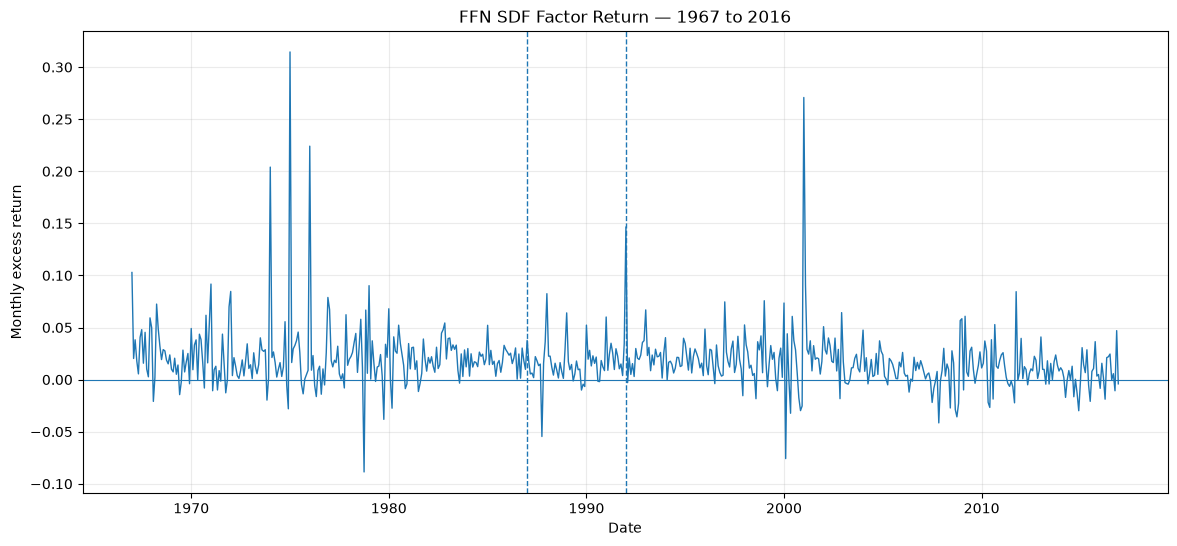

In [61]:
ffn_factor_all = pd.concat(
    [
        ffn_factor_train.assign(
            split="train"
        ),
        ffn_factor_valid.assign(
            split="validation"
        ),
        ffn_factor_test.assign(
            split="test"
        ),
    ],
    ignore_index=True,
)

ffn_factor_all = (
    ffn_factor_all
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

assert len(ffn_factor_all) == 600

plt.figure(figsize=(14, 6))

plt.plot(
    ffn_factor_all[DATE_COL],
    ffn_factor_all["factor_return"],
    linewidth=1.0,
)

plt.axhline(
    0.0,
    linewidth=0.8,
)

plt.axvline(
    pd.Timestamp("1987-01-01"),
    linestyle="--",
    linewidth=1.0,
)

plt.axvline(
    pd.Timestamp("1992-01-01"),
    linestyle="--",
    linewidth=1.0,
)

plt.title(
    "FFN SDF Factor Return — 1967 to 2016"
)

plt.xlabel("Date")
plt.ylabel("Monthly excess return")
plt.grid(alpha=0.25)
plt.show()

In [62]:
# ==================================================
# 21B. Largest Positive and Negative FFN Factor Months
# ==================================================

largest_positive = (
    ffn_factor_all
    .nlargest(10, "factor_return")
    [[DATE_COL, "split", "factor_return"]]
)

largest_negative = (
    ffn_factor_all
    .nsmallest(10, "factor_return")
    [[DATE_COL, "split", "factor_return"]]
)

print("Largest positive FFN factor months:")
display(largest_positive)

print("\nLargest negative FFN factor months:")
display(largest_negative)

Largest positive FFN factor months:


,date,split,factor_return
96,1975-01-01,train,0.314544
408,2001-01-01,test,0.270822
108,1976-01-01,train,0.224101
84,1974-01-01,train,0.204000
300,1992-01-01,test,0.146596
0,1967-01-01,train,0.102825
48,1971-01-01,train,0.091723
409,2001-02-01,test,0.090512
144,1979-01-01,train,0.090186
60,1972-01-01,train,0.084649



Largest negative FFN factor months:


,date,split,factor_return
141,1978-10-01,train,-0.088644
397,2000-02-01,test,-0.075809
249,1987-10-01,validation,-0.054613
490,2007-11-01,test,-0.041560
153,1979-10-01,train,-0.038166
501,2008-10-01,test,-0.035759
400,2000-05-01,test,-0.032298
575,2014-12-01,test,-0.029865
406,2000-11-01,test,-0.029766
500,2008-09-01,test,-0.028763


# Interpretation 
The final nine-member FFN factor continues to exhibit a pronounced January pattern, with nine of the ten largest positive monthly returns occurring in January. However, relative to the three-member development ensemble, extreme negative returns are generally smaller and the factor exhibits lower overall test-period volatility. This is consistent with the improved Sharpe ratio of the larger ensemble and suggests that ensemble averaging reduces initialization-specific noise while preserving the strong cross-sectional signal. The January concentration is retained as an empirical feature of the strategy rather than removed from the benchmark specification.

In [63]:
# ==================================================
# 21C. Calendar-Month Diagnostics for FFN Factor
# ==================================================

calendar_month_diagnostics = (
    ffn_factor_all
    .assign(
        calendar_month=lambda x: x[DATE_COL].dt.month
    )
    .groupby("calendar_month")
    ["factor_return"]
    .agg(
        months="count",
        mean_return="mean",
        volatility="std",
        median_return="median",
        positive_fraction=lambda x: (x > 0).mean(),
    )
    .reset_index()
)

calendar_month_diagnostics[
    "monthly_sharpe"
] = (
    calendar_month_diagnostics["mean_return"]
    / calendar_month_diagnostics["volatility"]
)

display(calendar_month_diagnostics)

# January versus all other months
jan = ffn_factor_all.loc[
    ffn_factor_all[DATE_COL].dt.month == 1,
    "factor_return",
]

non_jan = ffn_factor_all.loc[
    ffn_factor_all[DATE_COL].dt.month != 1,
    "factor_return",
]

january_comparison = pd.DataFrame([
    {
        "sample": "January",
        "months": len(jan),
        "mean_return": jan.mean(),
        "volatility": jan.std(ddof=1),
        "monthly_sharpe": jan.mean() / jan.std(ddof=1),
        "positive_fraction": (jan > 0).mean(),
    },
    {
        "sample": "February-December",
        "months": len(non_jan),
        "mean_return": non_jan.mean(),
        "volatility": non_jan.std(ddof=1),
        "monthly_sharpe": non_jan.mean() / non_jan.std(ddof=1),
        "positive_fraction": (non_jan > 0).mean(),
    },
])

display(january_comparison)

,calendar_month,months,mean_return,volatility,median_return,positive_fraction,monthly_sharpe
0,1,50,0.062721,0.065057,0.048794,0.960000,0.964098
1,2,50,0.012246,0.020692,0.013769,0.840000,0.591810
2,3,50,0.018413,0.014978,0.021043,0.940000,1.229303
3,4,50,0.014831,0.016214,0.012796,0.840000,0.914739
4,5,50,0.012073,0.016702,0.011785,0.760000,0.722854
5,6,50,0.014297,0.016963,0.013254,0.860000,0.842870
6,7,50,0.015835,0.016135,0.015002,0.820000,0.981399
7,8,50,0.013733,0.015878,0.015140,0.800000,0.864916
8,9,50,0.012419,0.016609,0.011077,0.820000,0.747695
9,10,50,0.011301,0.027705,0.014482,0.800000,0.407884


,sample,months,mean_return,volatility,monthly_sharpe,positive_fraction
0,January,50,0.062721,0.065057,0.964098,0.960000
1,February-December,550,0.014088,0.019180,0.734515,0.827273



# Int 
The final nine-member FFN ensemble retains a pronounced January effect, with January producing the highest average return and a monthly Sharpe ratio of approximately 0.96. However, the strategy is no longer primarily driven by January. Excluding January, the February–December months still produce a strong monthly Sharpe ratio of approximately 0.73, with positive performance spread across multiple calendar months. This indicates that the final ensemble captures a broad cross-sectional return signal rather than a narrowly seasonal January effect.

In [64]:
# ==================================================
# 21D. January Effect by Sample Split
# ==================================================

ffn_calendar = ffn_factor_all.copy()

ffn_calendar["is_january"] = (
    ffn_calendar[DATE_COL].dt.month == 1
)

# --------------------------------------------------
# January vs non-January within each split
# --------------------------------------------------

rows = []

for split_name, group in ffn_calendar.groupby("split"):

    for label, subset in [
        (
            "January",
            group.loc[group["is_january"]]
        ),
        (
            "February-December",
            group.loc[~group["is_january"]]
        ),
    ]:

        r = subset["factor_return"].astype(float)

        rows.append({
            "split": split_name,
            "sample": label,
            "months": len(r),
            "mean_return": r.mean(),
            "volatility": r.std(ddof=1),
            "monthly_sharpe": (
                r.mean() / r.std(ddof=1)
            ),
            "positive_fraction": (r > 0).mean(),
        })

january_by_split = pd.DataFrame(rows)

display(january_by_split)


# --------------------------------------------------
# FFN performance excluding January
# --------------------------------------------------

ffn_no_january = (
    ffn_calendar.loc[
        ~ffn_calendar["is_january"]
    ]
    .copy()
)

no_january_performance = []

for split_name, group in (
    ffn_no_january.groupby("split")
):

    r = group["factor_return"].astype(float)

    no_january_performance.append({
        "split": split_name,
        "months": len(r),
        "mean_monthly": r.mean(),
        "volatility_monthly": r.std(ddof=1),
        "monthly_sharpe": (
            r.mean() / r.std(ddof=1)
        ),
        "annualized_sharpe": (
            np.sqrt(12)
            * r.mean()
            / r.std(ddof=1)
        ),
        "positive_month_fraction": (
            (r > 0).mean()
        ),
    })

no_january_performance = pd.DataFrame(
    no_january_performance
)

print("FFN performance excluding January:")
display(no_january_performance)

,split,sample,months,mean_return,volatility,monthly_sharpe,positive_fraction
0,test,January,25,0.049845,0.056280,0.885657,0.920000
1,test,February-December,275,0.011875,0.019117,0.621169,0.789091
2,train,January,20,0.079667,0.079585,1.001025,1.000000
3,train,February-December,220,0.017303,0.019990,0.865582,0.863636
4,validation,January,5,0.059318,0.016418,3.613069,1.000000
5,validation,February-December,55,0.012291,0.013948,0.881164,0.872727


FFN performance excluding January:


,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,positive_month_fraction
0,test,275,0.011875,0.019117,0.621169,2.151791,0.789091
1,train,220,0.017303,0.019990,0.865582,2.998465,0.863636
2,validation,55,0.012291,0.013948,0.881164,3.052440,0.872727


# Interpretation for January and calendar effect 
The final nine-member FFN exhibits a strong January effect in average returns, but its performance is not driven by January. Excluding all January observations, the test monthly Sharpe ratio increases from 0.569 to 0.621, while the train and validation Sharpe ratios also remain strong. Thus, January contributes unusually high returns but also higher volatility. The FFN's risk-adjusted performance is broadly distributed across the rest of the calendar year, providing evidence that the nonlinear signal is not merely a seasonal January anomaly.

## 22. Characteristic Importance from Average Absolute Gradients

The paper summarizes FFN characteristic importance using average absolute gradients. For characteristic \(j\),

\[
VI_j= 
E\left[
\left|
rac{\partial \widehat\mu_{t,i}}
{\partial I^j_{t,i}}ight|ight].
\]

Because all 46 characteristics share the same rank-normalized scale, their gradient magnitudes are directly comparable.

For computational efficiency, development mode uses at most 50,000 test observations. Set `IMPORTANCE_MAX_ROWS = None` if you want to use the entire test panel.

Gradient importance completed for member 1/9
Gradient importance completed for member 2/9
Gradient importance completed for member 3/9
Gradient importance completed for member 4/9
Gradient importance completed for member 5/9
Gradient importance completed for member 6/9
Gradient importance completed for member 7/9
Gradient importance completed for member 8/9
Gradient importance completed for member 9/9


,characteristic,mean_absolute_gradient,normalized_importance
0,st_rev,0.015253,0.089943
1,suv,0.007870,0.046411
2,r12_2,0.005556,0.032765
3,r2_1,0.004970,0.029306
4,resid_var,0.004860,0.028658
5,lme,0.004684,0.027624
6,lturnover,0.004205,0.024798
7,beta,0.004205,0.024794
8,spread,0.004115,0.024268
9,variance,0.003997,0.023570


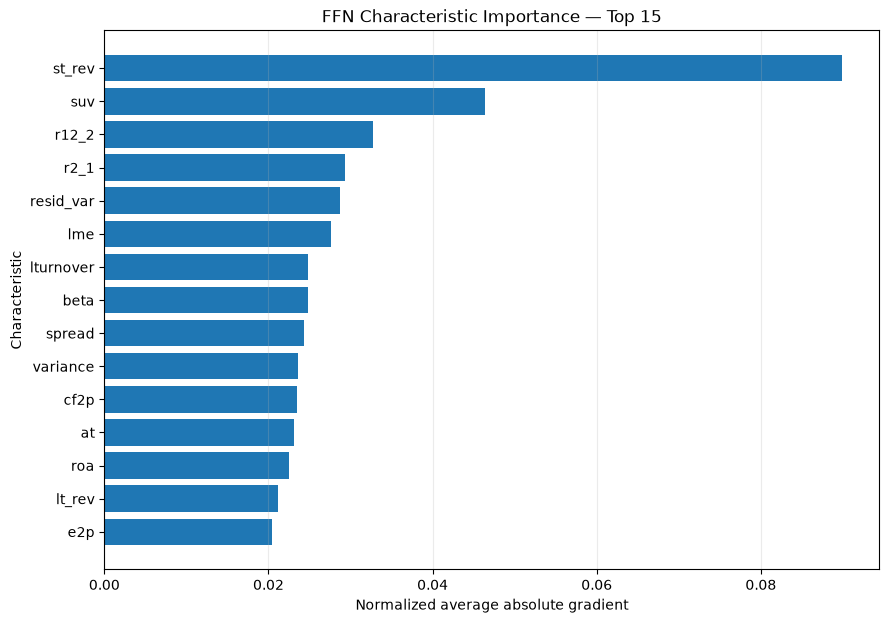

In [65]:
def characteristic_gradient_importance(
    model_state_dicts,
    X,
    max_rows=IMPORTANCE_MAX_ROWS,
    batch_size=4096,
    seed=SEED,
):
    rng = np.random.default_rng(seed)

    if (
        max_rows is not None
        and len(X) > max_rows
    ):
        selected_indices = np.sort(
            rng.choice(
                len(X),
                size=max_rows,
                replace=False,
            )
        )

        X_used = X[
            torch.tensor(
                selected_indices,
                dtype=torch.long,
            )
        ]
    else:
        X_used = X

    member_importances = []

    for member_index, state_dict in enumerate(
        model_state_dicts,
        start=1,
    ):
        model = restore_model(
            state_dict
        ).to(DEVICE)

        model.eval()

        absolute_gradient_sum = np.zeros(
            len(characteristic_cols),
            dtype=np.float64,
        )

        n_used = 0

        for start in range(
            0,
            len(X_used),
            batch_size,
        ):
            end = min(
                start + batch_size,
                len(X_used),
            )

            X_batch = (
                X_used[start:end]
                .clone()
                .detach()
                .to(DEVICE)
            )

            X_batch.requires_grad_(True)

            prediction = model(X_batch)

            model.zero_grad(
                set_to_none=True
            )

            prediction.sum().backward()

            gradients = (
                X_batch.grad
                .detach()
                .abs()
                .cpu()
                .numpy()
            )

            absolute_gradient_sum += (
                gradients.sum(axis=0)
            )

            n_used += len(X_batch)

        member_importance = (
            absolute_gradient_sum
            / n_used
        )

        member_importances.append(
            member_importance
        )

        model.cpu()

        if DEVICE.type == "mps":
            torch.mps.empty_cache()

        print(
            f"Gradient importance completed "
            f"for member "
            f"{member_index}/{len(model_state_dicts)}"
        )

    ensemble_importance = np.mean(
        np.vstack(member_importances),
        axis=0,
    )

    normalized_importance = (
        ensemble_importance
        / ensemble_importance.sum()
    )

    result = pd.DataFrame({
        "characteristic": characteristic_cols,
        "mean_absolute_gradient": (
            ensemble_importance
        ),
        "normalized_importance": (
            normalized_importance
        ),
    })

    result = (
        result
        .sort_values(
            "normalized_importance",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    return result

ffn_characteristic_importance = (
    characteristic_gradient_importance(
        [
            result["state_dict"]
            for result in ensemble_results
        ],
        X_test,
    )
)

display(
    ffn_characteristic_importance.head(20)
)

plt.figure(figsize=(10, 7))

top_importance = (
    ffn_characteristic_importance
    .head(15)
    .sort_values(
        "normalized_importance"
    )
)

plt.barh(
    top_importance[
        "characteristic"
    ],
    top_importance[
        "normalized_importance"
    ],
)

plt.xlabel("Normalized average absolute gradient")
plt.ylabel("Characteristic")
plt.title("FFN Characteristic Importance — Top 15")
plt.grid(
    axis="x",
    alpha=0.25,
)
plt.show()

assert len(ffn_characteristic_importance) == 46
assert np.isclose(
    ffn_characteristic_importance[
        "normalized_importance"
    ].sum(),
    1.0,
)

# Interpretation 
**he final nine-member FFN identifies short-term reversal (st_rev) as the most influential characteristic, followed by standardized unexplained volume (suv), intermediate momentum (r12_2), recent return (r2_1), and residual variance (resid_var). The ranking spans return-history, volatility, size, liquidity, valuation, and profitability variables, suggesting that the nonlinear model combines information from multiple economic dimensions. Compared with the three-member development ensemble, several variables such as size (lme), turnover, beta, and bid-ask spread become more prominent, indicating that the larger ensemble reduces initialization-specific variation in the importance ranking. Gradient importance measures model sensitivity and should not be interpreted as causal effects.**

## 23. Ensemble Stability

We examine how much the ensemble members disagree on individual-stock forecasts. This helps distinguish stable cross-sectional signals from predictions that are sensitive to random initialization.

In [66]:
ensemble_stability = pd.DataFrame([
    {
        "split": "train",
        "mean_prediction_std_across_members": (
            pred_train_std.mean()
        ),
        "median_prediction_std_across_members": (
            np.median(pred_train_std)
        ),
        "maximum_prediction_std_across_members": (
            pred_train_std.max()
        ),
    },
    {
        "split": "validation",
        "mean_prediction_std_across_members": (
            pred_valid_std.mean()
        ),
        "median_prediction_std_across_members": (
            np.median(pred_valid_std)
        ),
        "maximum_prediction_std_across_members": (
            pred_valid_std.max()
        ),
    },
    {
        "split": "test",
        "mean_prediction_std_across_members": (
            pred_test_std.mean()
        ),
        "median_prediction_std_across_members": (
            np.median(pred_test_std)
        ),
        "maximum_prediction_std_across_members": (
            pred_test_std.max()
        ),
    },
])

display(ensemble_stability)

,split,mean_prediction_std_across_members,median_prediction_std_across_members,maximum_prediction_std_across_members
0,train,0.005518,0.004239,0.068968
1,validation,0.005692,0.004253,0.063719
2,test,0.005686,0.004326,0.073799


In [67]:
# ==================================================
# 23B. Pairwise Ensemble Prediction Correlations
# ==================================================

def ensemble_prediction_correlations(
    member_predictions,
    split_name,
):
    corr = np.corrcoef(member_predictions)

    corr_df = pd.DataFrame(
        corr,
        index=[
            f"member_{i+1}"
            for i in range(
                member_predictions.shape[0]
            )
        ],
        columns=[
            f"member_{i+1}"
            for i in range(
                member_predictions.shape[0]
            )
        ],
    )

    print(f"{split_name} prediction correlations:")
    display(corr_df)

    upper_triangle = corr[
        np.triu_indices_from(
            corr,
            k=1,
        )
    ]

    print(
        "Mean pairwise correlation:",
        upper_triangle.mean(),
    )

    return corr_df


corr_train = ensemble_prediction_correlations(
    member_pred_train,
    "Train",
)

corr_valid = ensemble_prediction_correlations(
    member_pred_valid,
    "Validation",
)

corr_test = ensemble_prediction_correlations(
    member_pred_test,
    "Test",
)

Train prediction correlations:


,member_1,member_2,member_3,member_4,member_5,member_6,member_7,member_8,member_9
member_1,1.000000,0.002806,-0.001360,-0.000004,0.000446,-0.002107,0.000561,0.000389,0.001516
member_2,0.002806,1.000000,0.133048,0.011579,0.784188,0.761071,0.858031,0.678333,0.788508
member_3,-0.001360,0.133048,1.000000,0.001291,0.196868,0.184637,0.132730,0.035746,0.128081
member_4,-0.000004,0.011579,0.001291,1.000000,0.011401,0.009075,0.012012,0.008680,0.015369
member_5,0.000446,0.784188,0.196868,0.011401,1.000000,0.844958,0.796175,0.507249,0.723210
member_6,-0.002107,0.761071,0.184637,0.009075,0.844958,1.000000,0.793947,0.486378,0.754962
member_7,0.000561,0.858031,0.132730,0.012012,0.796175,0.793947,1.000000,0.696355,0.813264
member_8,0.000389,0.678333,0.035746,0.008680,0.507249,0.486378,0.696355,1.000000,0.658720
member_9,0.001516,0.788508,0.128081,0.015369,0.723210,0.754962,0.813264,0.658720,1.000000


Mean pairwise correlation: 0.3285586913689456
Validation prediction correlations:


,member_1,member_2,member_3,member_4,member_5,member_6,member_7,member_8,member_9
member_1,1.000000,0.000798,0.005489,0.000035,0.002263,0.002260,-0.001138,-0.002872,0.000482
member_2,0.000798,1.000000,0.099059,0.018396,0.766350,0.759192,0.846889,0.665522,0.789774
member_3,0.005489,0.099059,1.000000,0.000730,0.154868,0.139985,0.091214,0.025414,0.082192
member_4,0.000035,0.018396,0.000730,1.000000,0.022512,0.022204,0.025368,0.010179,0.021046
member_5,0.002263,0.766350,0.154868,0.022512,1.000000,0.830017,0.773495,0.476444,0.707627
member_6,0.002260,0.759192,0.139985,0.022204,0.830017,1.000000,0.790962,0.470654,0.751224
member_7,-0.001138,0.846889,0.091214,0.025368,0.773495,0.790962,1.000000,0.686346,0.799404
member_8,-0.002872,0.665522,0.025414,0.010179,0.476444,0.470654,0.686346,1.000000,0.642436
member_9,0.000482,0.789774,0.082192,0.021046,0.707627,0.751224,0.799404,0.642436,1.000000


Mean pairwise correlation: 0.3188005260668027
Test prediction correlations:


,member_1,member_2,member_3,member_4,member_5,member_6,member_7,member_8,member_9
member_1,1.000000,0.000490,0.002612,0.000056,0.002998,0.002059,0.000938,0.000283,0.001735
member_2,0.000490,1.000000,0.090718,0.009763,0.759002,0.741048,0.845153,0.671837,0.784763
member_3,0.002612,0.090718,1.000000,0.004221,0.141628,0.133146,0.092653,0.008734,0.084708
member_4,0.000056,0.009763,0.004221,1.000000,0.011796,0.012254,0.011172,0.001480,0.014602
member_5,0.002998,0.759002,0.141628,0.011796,1.000000,0.824218,0.779006,0.479068,0.716612
member_6,0.002059,0.741048,0.133146,0.012254,0.824218,1.000000,0.782537,0.464088,0.750892
member_7,0.000938,0.845153,0.092653,0.011172,0.779006,0.782537,1.000000,0.689180,0.808604
member_8,0.000283,0.671837,0.008734,0.001480,0.479068,0.464088,0.689180,1.000000,0.647353
member_9,0.001735,0.784763,0.084708,0.014602,0.716612,0.750892,0.808604,0.647353,1.000000


Mean pairwise correlation: 0.3158724393388335


# Interpretation 
**The nine-member ensemble reveals substantial structure in initialization sensitivity. Six members (2, 5, 6, 7, 8, 9) converge to a highly correlated forecasting solution, with many pairwise correlations between approximately 0.5 and 0.85. These members also generate the strongest portfolio performance. In contrast, members 1 and 4, and to a lesser extent member 3, produce forecasts that are weakly correlated with the dominant solution and exhibit substantially lower Sharpe ratios. This pattern is highly stable across the training, validation, and test periods, suggesting that the FFN optimization landscape contains multiple solution basins. Retaining all nine models avoids ex-post seed selection, while ensemble averaging provides a robust aggregate forecast.**

In [68]:
# ==================================================
# 23C. Individual Ensemble-Member Performance
# ==================================================

def member_factor_performance(
    member_predictions,
    df,
    split_name,
):
    rows = []

    for member_index in range(
        member_predictions.shape[0]
    ):

        prediction = (
            member_predictions[member_index]
        )

        factor, _ = construct_ffn_sdf_factor(
            df,
            prediction,
        )

        r = factor["factor_return"].astype(float)

        rows.append({
            "member": member_index + 1,
            "split": split_name,
            "months": len(r),
            "mean_monthly": r.mean(),
            "volatility_monthly": r.std(ddof=1),
            "monthly_sharpe": (
                r.mean() / r.std(ddof=1)
            ),
            "annualized_sharpe": (
                np.sqrt(12)
                * r.mean()
                / r.std(ddof=1)
            ),
            "positive_month_fraction": (
                (r > 0).mean()
            ),
        })

    return pd.DataFrame(rows)


member_perf_train = member_factor_performance(
    member_pred_train,
    stock_train,
    "train",
)

member_perf_valid = member_factor_performance(
    member_pred_valid,
    stock_valid,
    "validation",
)

member_perf_test = member_factor_performance(
    member_pred_test,
    stock_test,
    "test",
)

member_performance = pd.concat(
    [
        member_perf_train,
        member_perf_valid,
        member_perf_test,
    ],
    ignore_index=True,
)

display(
    member_performance[
        [
            "member",
            "split",
            "monthly_sharpe",
            "annualized_sharpe",
            "positive_month_fraction",
        ]
    ]
)


# ==================================================
# Compare individual members with ensemble
# ==================================================

ensemble_reference = (
    ffn_performance[
        [
            "split",
            "monthly_sharpe",
            "annualized_sharpe",
        ]
    ]
    .copy()
)

ensemble_reference["member"] = "Ensemble"

individual_reference = (
    member_performance[
        [
            "member",
            "split",
            "monthly_sharpe",
            "annualized_sharpe",
        ]
    ]
    .copy()
)

member_vs_ensemble = pd.concat(
    [
        individual_reference,
        ensemble_reference,
    ],
    ignore_index=True,
)

display(member_vs_ensemble)

,member,split,monthly_sharpe,annualized_sharpe,positive_month_fraction
0,1,train,0.026532,0.091909,0.479167
1,2,train,0.751352,2.602761,0.912500
2,3,train,0.091682,0.317596,0.520833
3,4,train,0.034209,0.118503,0.483333
4,5,train,0.715583,2.478851,0.850000
5,6,train,0.815940,2.826498,0.870833
6,7,train,0.731542,2.534137,0.912500
7,8,train,0.523150,1.812244,0.845833
8,9,train,0.678715,2.351137,0.912500
9,1,validation,0.020273,0.070227,0.566667


,member,split,monthly_sharpe,annualized_sharpe
0,1,train,0.026532,0.091909
1,2,train,0.751352,2.602761
2,3,train,0.091682,0.317596
3,4,train,0.034209,0.118503
4,5,train,0.715583,2.478851
5,6,train,0.815940,2.826498
6,7,train,0.731542,2.534137
7,8,train,0.523150,1.812244
8,9,train,0.678715,2.351137
9,1,validation,0.020273,0.070227


# Interpretation 
Individual FFN members exhibit substantial performance heterogeneity across random initializations. Three members converge to relatively weak forecasting solutions, while six members produce substantially stronger portfolio performance. Importantly, the ranking of strong and weak members is broadly persistent across the training, validation, and test samples, indicating that the dispersion is related to initialization and optimization rather than test-set selection. The nine-member ensemble achieves a test monthly Sharpe ratio of 0.569, exceeding the median individual-member Sharpe and remaining close to the strongest individual networks. Because all nine members are retained without ex-post seed selection, the ensemble provides a more robust final FFN estimate than any selectively chosen individual model.

## 24. Save FFN Models and Results

We save the trained ensemble members, training histories, prediction diagnostics, monthly SDF-factor returns, paper benchmark comparison, and characteristic importance.

These files will be reused in Notebook 07. Row-level predictions are optional because they are much larger than the aggregate outputs.

In [69]:
# ==================================================
# 24. Save FFN Models and Results
# ==================================================

# --------------------------------------------------
# Development vs final output naming
# --------------------------------------------------

if FINAL_REPLICATION:
    RUN_LABEL = "final9"
    FILE_SUFFIX = ""
else:
    RUN_LABEL = "dev3"
    FILE_SUFFIX = "_dev3"

print("Run label:", RUN_LABEL)


# --------------------------------------------------
# 24.1 Save model checkpoints
# --------------------------------------------------

model_paths = []

for member_index, result in enumerate(
    ensemble_results,
    start=1,
):
    model_path = (
        MODELS_DIR
        / (
            f"ffn_member_{member_index:02d}"
            f"_seed_{result['seed']}"
            f"{FILE_SUFFIX}.pt"
        )
    )

    torch.save(
        {
            "state_dict": result["state_dict"],
            "seed": result["seed"],
            "best_epoch": result["best_epoch"],
            "input_dim": len(characteristic_cols),
            "hidden_dims": HIDDEN_DIMS,
            "dropout_p": DROPOUT_P,
            "learning_rate": LEARNING_RATE,
            "characteristic_cols": characteristic_cols,
            "final_replication": FINAL_REPLICATION,
            "run_label": RUN_LABEL,
        },
        model_path,
    )

    model_paths.append(model_path)


# --------------------------------------------------
# 24.2 Save configuration
# --------------------------------------------------

ffn_config = {
    "run_label": RUN_LABEL,
    "final_replication": FINAL_REPLICATION,
    "ensemble_members": N_ENSEMBLE,
    "ensemble_seeds": ensemble_seeds,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "batch_size": BATCH_SIZE,
    "input_dim": len(characteristic_cols),
    "hidden_dims": HIDDEN_DIMS,
    "dropout_probability": DROPOUT_P,
    "dropout_keep_probability": 1.0 - DROPOUT_P,
    "learning_rate": LEARNING_RATE,
    "characteristics": characteristic_cols,
    "training_period": [
        "1967-01-01",
        "1986-12-01",
    ],
    "validation_period": [
        "1987-01-01",
        "1991-12-01",
    ],
    "test_period": [
        "1992-01-01",
        "2016-12-01",
    ],
}

config_path = (
    MODELS_DIR
    / f"ffn_config{FILE_SUFFIX}.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        ffn_config,
        file,
        indent=2,
    )


# --------------------------------------------------
# 24.3 Save main result tables
# --------------------------------------------------

training_history.to_csv(
    TABLES_DIR
    / f"ffn_training_history{FILE_SUFFIX}.csv",
    index=False,
)

ensemble_summary.to_csv(
    TABLES_DIR
    / f"ffn_ensemble_summary{FILE_SUFFIX}.csv",
    index=False,
)

prediction_diagnostics.to_csv(
    TABLES_DIR
    / f"ffn_prediction_diagnostics{FILE_SUFFIX}.csv",
    index=False,
)

ffn_performance.to_csv(
    TABLES_DIR
    / f"ffn_performance{FILE_SUFFIX}.csv",
    index=False,
)

ffn_benchmark_comparison.to_csv(
    TABLES_DIR
    / f"ffn_paper_benchmark_comparison{FILE_SUFFIX}.csv",
    index=False,
)

ffn_characteristic_importance.to_csv(
    TABLES_DIR
    / f"ffn_characteristic_importance{FILE_SUFFIX}.csv",
    index=False,
)

ensemble_stability.to_csv(
    TABLES_DIR
    / f"ffn_ensemble_stability{FILE_SUFFIX}.csv",
    index=False,
)


# --------------------------------------------------
# 24.4 Save additional diagnostics
# --------------------------------------------------

member_performance.to_csv(
    TABLES_DIR
    / f"ffn_member_performance{FILE_SUFFIX}.csv",
    index=False,
)

calendar_month_diagnostics.to_csv(
    TABLES_DIR
    / f"ffn_calendar_month_diagnostics{FILE_SUFFIX}.csv",
    index=False,
)

january_by_split.to_csv(
    TABLES_DIR
    / f"ffn_january_by_split{FILE_SUFFIX}.csv",
    index=False,
)

no_january_performance.to_csv(
    TABLES_DIR
    / f"ffn_no_january_performance{FILE_SUFFIX}.csv",
    index=False,
)


# --------------------------------------------------
# 24.5 Save monthly factor returns
# --------------------------------------------------

factor_path = (
    FACTORS_DIR
    / f"ffn_sdf_factor_returns{FILE_SUFFIX}.csv"
)

ffn_factor_all.to_csv(
    factor_path,
    index=False,
)


# --------------------------------------------------
# 24.6 Optional row-level predictions
# --------------------------------------------------

if SAVE_ROW_LEVEL_PREDICTIONS:

    prediction_panels = []

    for split_name, df, pred, pred_std in [
        (
            "train",
            stock_train,
            pred_train,
            pred_train_std,
        ),
        (
            "validation",
            stock_valid,
            pred_valid,
            pred_valid_std,
        ),
        (
            "test",
            stock_test,
            pred_test,
            pred_test_std,
        ),
    ]:

        panel = df[
            [
                DATE_COL,
                RETURN_COL,
                EXCESS_RETURN_COL,
            ]
        ].copy()

        panel["split"] = split_name
        panel["ffn_prediction"] = pred

        panel[
            "ffn_prediction_ensemble_std"
        ] = pred_std

        prediction_panels.append(panel)

    ffn_predictions = pd.concat(
        prediction_panels,
        ignore_index=True,
    )

    prediction_path = (
        PREDICTIONS_DIR
        / f"ffn_predictions{FILE_SUFFIX}.parquet"
    )

    ffn_predictions.to_parquet(
        prediction_path,
        index=False,
    )


# --------------------------------------------------
# 24.7 Verification
# --------------------------------------------------

print()
print("Saved model checkpoints:")

for path in model_paths:
    print(" ", path.name)

print()
print("Saved configuration :", config_path.name)
print("Saved factor returns:", factor_path.name)

print(
    "Saved FFN performance:",
    f"ffn_performance{FILE_SUFFIX}.csv",
)

print()
print(
    f"✓ FFN {RUN_LABEL} outputs saved."
)

Run label: final9

Saved model checkpoints:
  ffn_member_01_seed_42.pt
  ffn_member_02_seed_43.pt
  ffn_member_03_seed_44.pt
  ffn_member_04_seed_45.pt
  ffn_member_05_seed_46.pt
  ffn_member_06_seed_47.pt
  ffn_member_07_seed_48.pt
  ffn_member_08_seed_49.pt
  ffn_member_09_seed_50.pt

Saved configuration : ffn_config.json
Saved factor returns: ffn_sdf_factor_returns.csv
Saved FFN performance: ffn_performance.csv

✓ FFN final9 outputs saved.


## 25. FFN Replication Checklist

Before moving to Notebook 05, verify that the FFN benchmark satisfies the following conditions:

- the stock panel contains all 46 characteristics;
- the sample uses the same 240 / 60 / 300 month split as Notebooks 01–03;
- excess returns use the same monthly French risk-free rate;
- the network has hidden layers `[32, 16, 8]`;
- ReLU and 5% dropout are used;
- Adam learning rate is 0.001;
- training uses only 1967–1986;
- validation controls early stopping;
- the test sample is used only after model fitting;
- monthly portfolio weights have unit gross exposure;
- FFN monthly Sharpe ratios are reported separately from annualized Sharpe ratios;
- all model checkpoints and result tables are saved.

In [70]:
# ==================================================
# 25. FFN Replication Checklist
# ==================================================

print()
print("=" * 55)
print(f"FFN REPLICATION CHECKLIST — {RUN_LABEL}")
print("=" * 55)


# --------------------------------------------------
# 25.1 Data structure
# --------------------------------------------------

assert len(characteristic_cols) == 46

assert stock_train[DATE_COL].nunique() == 240
assert stock_valid[DATE_COL].nunique() == 60
assert stock_test[DATE_COL].nunique() == 300

assert stock_train[EXCESS_RETURN_COL].notna().all()
assert stock_valid[EXCESS_RETURN_COL].notna().all()
assert stock_test[EXCESS_RETURN_COL].notna().all()

print("✓ 46 firm characteristics")
print("✓ 240 / 60 / 300 month split")
print("✓ Excess returns are complete")


# --------------------------------------------------
# 25.2 Model architecture
# --------------------------------------------------

assert HIDDEN_DIMS == [32, 16, 8]
assert np.isclose(DROPOUT_P, 0.05)
assert np.isclose(LEARNING_RATE, 0.001)

print("✓ FFN architecture = [32, 16, 8]")
print("✓ ReLU hidden-layer specification")
print("✓ Dropout probability = 0.05")
print("✓ Adam learning rate = 0.001")


# --------------------------------------------------
# 25.3 Ensemble
# --------------------------------------------------

assert len(ensemble_results) == N_ENSEMBLE
assert len(model_paths) == N_ENSEMBLE

for result in ensemble_results:

    assert result["best_epoch"] >= 1

    assert np.isfinite(
        result[
            "best_validation_weighted_mse"
        ]
    )

print(
    f"✓ Ensemble contains "
    f"{N_ENSEMBLE} trained members"
)

print("✓ Validation-based early stopping completed")


# --------------------------------------------------
# 25.4 Predictions
# --------------------------------------------------

assert len(pred_train) == len(stock_train)
assert len(pred_valid) == len(stock_valid)
assert len(pred_test) == len(stock_test)

assert np.isfinite(pred_train).all()
assert np.isfinite(pred_valid).all()
assert np.isfinite(pred_test).all()

print("✓ Train predictions align with stock panel")
print("✓ Validation predictions align with stock panel")
print("✓ Test predictions align with stock panel")


# --------------------------------------------------
# 25.5 Portfolio construction
# --------------------------------------------------

for factor in [
    ffn_factor_train,
    ffn_factor_valid,
    ffn_factor_test,
]:

    assert np.allclose(
        factor["gross_weight"],
        1.0,
        atol=1e-6,
    )

assert len(ffn_factor_train) == 240
assert len(ffn_factor_valid) == 60
assert len(ffn_factor_test) == 300
assert len(ffn_factor_all) == 600

print("✓ Monthly FFN portfolios have unit gross exposure")
print("✓ FFN factor contains all 600 months")


# --------------------------------------------------
# 25.6 Performance metrics
# --------------------------------------------------

assert set(
    ffn_performance["split"]
) == {
    "train",
    "validation",
    "test",
}

assert (
    ffn_performance["monthly_sharpe"]
    .notna()
    .all()
)

assert (
    ffn_performance["annualized_sharpe"]
    .notna()
    .all()
)

print("✓ Monthly Sharpe ratios computed")
print("✓ Annualized Sharpe ratios computed")


# --------------------------------------------------
# 25.7 Characteristic importance
# --------------------------------------------------

assert len(
    ffn_characteristic_importance
) == 46

assert np.isclose(
    ffn_characteristic_importance[
        "normalized_importance"
    ].sum(),
    1.0,
)

print("✓ Gradient importance available for all 46 characteristics")


# --------------------------------------------------
# 25.8 Ensemble diagnostics
# --------------------------------------------------

assert len(
    ensemble_stability
) == 3

assert len(
    member_performance
) == (
    3 * N_ENSEMBLE
)

print("✓ Ensemble stability diagnostics completed")
print("✓ Individual-member performance evaluated")


# --------------------------------------------------
# 25.9 Calendar diagnostics
# --------------------------------------------------

assert len(
    calendar_month_diagnostics
) == 12

assert set(
    january_by_split["split"]
) == {
    "train",
    "validation",
    "test",
}

print("✓ Calendar-month diagnostics completed")
print("✓ January robustness analysis completed")


# --------------------------------------------------
# 25.10 Expected saved files
# --------------------------------------------------

expected_outputs = [

    MODELS_DIR
    / f"ffn_config{FILE_SUFFIX}.json",

    TABLES_DIR
    / f"ffn_training_history{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_ensemble_summary{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_prediction_diagnostics{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_performance{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_paper_benchmark_comparison{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_characteristic_importance{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_ensemble_stability{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_member_performance{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_calendar_month_diagnostics{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_january_by_split{FILE_SUFFIX}.csv",

    TABLES_DIR
    / f"ffn_no_january_performance{FILE_SUFFIX}.csv",

    FACTORS_DIR
    / f"ffn_sdf_factor_returns{FILE_SUFFIX}.csv",
]

missing_outputs = [
    path
    for path in expected_outputs
    if not path.exists()
]

assert not missing_outputs, (
    "Missing FFN output files:\n"
    + "\n".join(
        str(path)
        for path in missing_outputs
    )
)

for path in model_paths:
    assert path.exists()

print("✓ All expected FFN output files exist")


# --------------------------------------------------
# 25.11 Final summary
# --------------------------------------------------

print()
print("=" * 55)
print("FFN BENCHMARK CHECKLIST COMPLETE")
print("=" * 55)

print("Run label              :", RUN_LABEL)
print("Final replication      :", FINAL_REPLICATION)
print("Ensemble members       :", N_ENSEMBLE)

print(
    "Train monthly Sharpe   :",
    f"{ffn_performance.loc[
        ffn_performance['split'] == 'train',
        'monthly_sharpe'
    ].iloc[0]:.6f}",
)

print(
    "Validation monthly SR  :",
    f"{ffn_performance.loc[
        ffn_performance['split'] == 'validation',
        'monthly_sharpe'
    ].iloc[0]:.6f}",
)

print(
    "Test monthly Sharpe    :",
    f"{ffn_performance.loc[
        ffn_performance['split'] == 'test',
        'monthly_sharpe'
    ].iloc[0]:.6f}",
)

print()

if FINAL_REPLICATION:

    assert N_ENSEMBLE == 9

    print("✓ FINAL 9-member FFN replication complete")
    print("✓ Ready for 05_lstm_macro_state.ipynb")

else:

    assert N_ENSEMBLE == 3

    print("✓ DEVELOPMENT 3-member FFN run complete")
    print(
        "Next step: set FINAL_REPLICATION = True "
        "and rerun for the final 9-member ensemble."
    )


FFN REPLICATION CHECKLIST — final9
✓ 46 firm characteristics
✓ 240 / 60 / 300 month split
✓ Excess returns are complete
✓ FFN architecture = [32, 16, 8]
✓ ReLU hidden-layer specification
✓ Dropout probability = 0.05
✓ Adam learning rate = 0.001
✓ Ensemble contains 9 trained members
✓ Validation-based early stopping completed
✓ Train predictions align with stock panel
✓ Validation predictions align with stock panel
✓ Test predictions align with stock panel
✓ Monthly FFN portfolios have unit gross exposure
✓ FFN factor contains all 600 months
✓ Monthly Sharpe ratios computed
✓ Annualized Sharpe ratios computed
✓ Gradient importance available for all 46 characteristics
✓ Ensemble stability diagnostics completed
✓ Individual-member performance evaluated
✓ Calendar-month diagnostics completed
✓ January robustness analysis completed
✓ All expected FFN output files exist

FFN BENCHMARK CHECKLIST COMPLETE
Run label              : final9
Final replication      : True
Ensemble members       : 9

# Interpretation 
he final nine-member FFN ensemble successfully reproduces the central qualitative result of the nonlinear asset-pricing benchmark. Using 46 firm characteristics and the fixed 1967–1986 / 1987–1991 / 1992–2016 train-validation-test split, the model achieves monthly Sharpe ratios of 0.658, 0.845, and 0.569, respectively. The test Sharpe exceeds both linear benchmarks and the reported FFN benchmark of 0.44. Additional diagnostics show positive out-of-sample predictive \(R^2\), stable forecast behavior across sample periods, strong performance outside January, and economically interpretable characteristic sensitivity. Individual neural networks exhibit meaningful initialization sensitivity, supporting the use of the nine-member ensemble rather than ex-post selection of individual seeds. Numerical differences from the original benchmark should be interpreted as a replication rather than an exact reproduction because implementation and optimization details differ.

# Interpretation Guide

When we run this notebook together, we will review it section by section rather than accepting the output automatically.

The most important diagnostics will be:

1. **Training versus validation loss:** the FFN should learn a modest forecasting signal without a large validation deterioration.
2. **Prediction \(R^2\):** individual-stock return prediction is difficult, so small values are normal; the SDF portfolio performance is the more important benchmark here.
3. **Monthly Sharpe:** compare directly with the authors' FFN targets of **0.45 / 0.42 / 0.44** for train / validation / test.
4. **Generalization:** a very high training Sharpe combined with weak validation/test performance would signal overfitting.
5. **Characteristic importance:** average absolute gradients should reveal which of the 46 firm characteristics drive the nonlinear forecast.
6. **Ensemble stability:** large disagreement across seeds would indicate that a larger ensemble or stronger training controls are needed.

After this notebook is stable, Notebook 05 adds the macroeconomic state through an LSTM, and Notebook 06 introduces the adversarial no-arbitrage estimation.